# Loss Prediction Model

Your task is to build a model that predicts whether a new insurance record is likely to be **loss-making** — i.e. whether `is_loss_making` will be `True` (which occurs when `loss_ratio > 1.0`, meaning costs exceeded the premium charged).

Work through the sections below. The data is already loaded for you.

**What we care about:**
- How you explore and understand the data before modelling
- Why you chose the model you did
- How you would think about explainability — a reviewer needs to understand *why* a record is flagged
- What the limitations of your model are

When you are done, save your trained model artifact to `../app/artifacts/model.pkl` (Section 4).

In [1]:
import pickle
import warnings
from pathlib import Path

import category_encoders as ce
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")
%matplotlib inline
sns.set_theme(style="whitegrid")

In [60]:
DATA_PATH = Path("../data/records.csv")

df = pd.read_csv(DATA_PATH)

# Normalise categoricals at load time so all downstream cells see clean values
for col in ["risk_type", "territory", "industry", "broker"]:
    df[col] = df[col].str.strip().str.lower()

print(f"Shape: {df.shape}")
df.head()

Shape: (504, 11)


,record_id,risk_type,territory,industry,limit,premium,broker,prior_claims,years_trading,loss_ratio,is_loss_making
0,REC_0001,property,uk,healthcare,665000,15200,nexus broking,1.0,28.0,1.0210,True
1,REC_0002,cyber,apac,healthcare,4126000,104900,meridian re,1.0,11.0,0.9007,False
2,REC_0003,cyber,latam,energy,906000,5900,meridian re,1.0,7.0,1.1317,True
3,REC_0004,marine,latam,transport,1008000,13200,caldwell specialty,1.0,1.0,0.8293,False
4,REC_0005,marine,us,manufacturing,9195000,89200,pinnacle mga,1.0,1.0,0.9607,True


## 1. Data Exploration

Understand the data before touching the model. Things worth checking:
- Shape, dtypes, missing values
- Class balance (how many loss-making records?)
- Distributions of numeric features
- Relationships between features and the target
- Anything unexpected in the data

In [61]:
# inspect dtypes and missing values
print("Shape:", df.shape)
print("\nDtypes:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nSample rows:")
df.head()

Shape: (504, 11)

Dtypes:
record_id          object
risk_type          object
territory          object
industry           object
limit               int64
premium             int64
broker             object
prior_claims      float64
years_trading     float64
loss_ratio        float64
is_loss_making       bool
dtype: object

Missing values:
record_id          0
risk_type          0
territory          0
industry          21
limit              0
premium            0
broker             0
prior_claims      20
years_trading     20
loss_ratio         0
is_loss_making     0
dtype: int64

Sample rows:


,record_id,risk_type,territory,industry,limit,premium,broker,prior_claims,years_trading,loss_ratio,is_loss_making
0,REC_0001,property,uk,healthcare,665000,15200,nexus broking,1.0,28.0,1.0210,True
1,REC_0002,cyber,apac,healthcare,4126000,104900,meridian re,1.0,11.0,0.9007,False
2,REC_0003,cyber,latam,energy,906000,5900,meridian re,1.0,7.0,1.1317,True
3,REC_0004,marine,latam,transport,1008000,13200,caldwell specialty,1.0,1.0,0.8293,False
4,REC_0005,marine,us,manufacturing,9195000,89200,pinnacle mga,1.0,1.0,0.9607,True


## Is loss making

This is derived from when loss_ratio > 0. 

Plan:
1. Look for extreme loss ratios
2. Visualise
2. Consider target engineering

In [62]:
df['loss_ratio'].sort_values().tail(10)

462     1.3481
97      1.3676
475     1.5234
412     1.5593
352     6.8000
325     8.2000
387     9.4000
28     11.7000
179    12.3000
437    15.0000
Name: loss_ratio, dtype: float64

I'm going to consider everything above a loss ratio of 6 an outlier here. However, since we have very few rows in our training set, and we're going to cast the loss ratio into a binary output, I'll leave them in.

Now lets visualise:

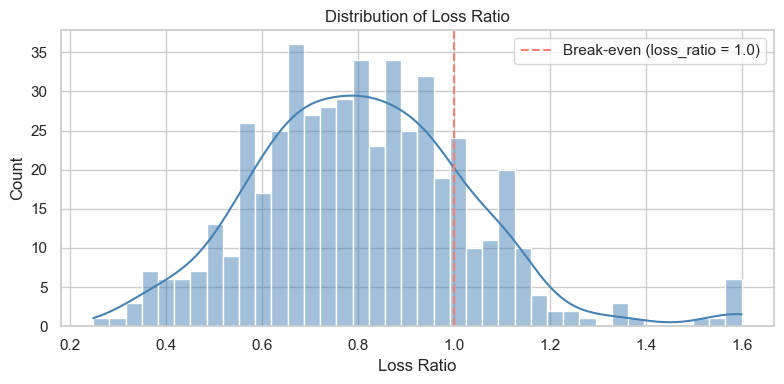

count    504.0000
mean       0.9154
std        1.1212
min        0.2475
25%        0.6591
50%        0.8002
75%        0.9434
max       15.0000
Name: loss_ratio, dtype: float64


In [63]:
# Distribution of loss_ratio
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df["loss_ratio"].clip(upper=1.6), bins=40, kde=True, color="steelblue", ax=ax)
ax.axvline(1.0, color="salmon", linestyle="--", linewidth=1.5, label="Break-even (loss_ratio = 1.0)")
ax.set_xlabel("Loss Ratio")
ax.set_ylabel("Count")
ax.set_title("Distribution of Loss Ratio")
ax.legend()
plt.tight_layout()
plt.show()

print(df["loss_ratio"].describe().round(4))

I'm going to recast the target to be when the loss ratio is greater than 0.8. Here are my reasons:
1. In insurance, the premium pays out every year
2. However, payouts happen stochastically
3. Imagine a product with a premium of £1, and a 1/10 chance of paying out £10. For the first few years, if there hadn't been a payout, the loss ratio would be zero. 
4. However, the loss ratio of this product would be 1.
5. There is also an asymmetry in the cost of doing some extra investigations into a possible loss-making product, and in the cost of underwriting a product that is loss-making.
6. Therefore, I'm going to lower the target to anything over 0.8.
7. This also balances the target, which is preferable from and ML perspective (although not the primary motivation)

In [64]:
df.loc[:,'is_loss_making'] = df['loss_ratio'] > 0.8

Class counts:
is_loss_making
True     253
False    251
Name: count, dtype: int64

Loss-making: 253 (50.2%)
Not loss-making: 251 (49.8%)


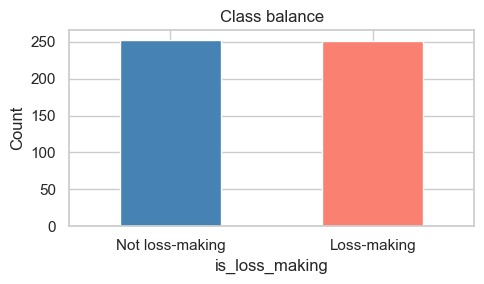

In [65]:
# check class balance — how many records are loss-making?
balance = df["is_loss_making"].value_counts()
pct = df["is_loss_making"].value_counts(normalize=True) * 100

print("Class counts:")
print(balance)
print(f"\nLoss-making: {balance[True]} ({pct[True]:.1f}%)")
print(f"Not loss-making: {balance[False]} ({pct[False]:.1f}%)")

fig, ax = plt.subplots(figsize=(5, 3))
balance.plot(kind="bar", ax=ax, color=["steelblue", "salmon"])
ax.set_xticklabels(["Not loss-making", "Loss-making"], rotation=0)
ax.set_title("Class balance")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

## Feature investigation

## Limit

Limit is the maximum the policy will pay out, in the event it is triggered.

Plan:
1. Look for outliers and decide what to do
2. Visualise

In [66]:
df['limit'].sort_values().head(10)

142        50
157    501000
220    502000
313    511000
322    513000
100    518000
44     548000
68     556000
355    558000
204    565000
Name: limit, dtype: int64

In [67]:
df['limit'].sort_values().tail(10)

344     46053000
187     47835000
22      48149000
129     48201000
383     48535000
477     48820000
259     49241000
108     49681000
130     49867000
379    999999999
Name: limit, dtype: int64

Rows 142 and 379 have limits of 50 and 999999999 respectively. These seem like outliers. I'm going to cast them into the median values of their column. They also appear to be transcription errors, so I'll avoid the magnitudes of them. This is to continue the policy of keeping as many items in our dataset as possible

In [68]:
median_limit = df['limit'].median()
df.loc[df['limit'] == 50, 'limit'] = median_limit
df.loc[df['limit'] == 999999999, 'limit'] = median_limit

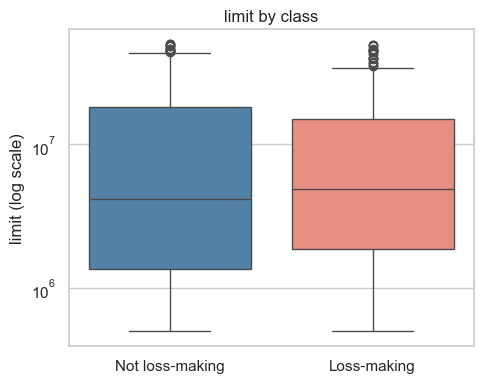

In [69]:
# Box plot — distribution of limit by class
df_plot = df.copy()
df_plot["Class"] = df_plot["is_loss_making"].map({False: "Not loss-making", True: "Loss-making"})

fig, ax = plt.subplots(figsize=(5, 4))
sns.boxplot(
    data=df_plot, x="Class", y="limit", ax=ax,
    palette={"Not loss-making": "steelblue", "Loss-making": "salmon"},
    order=["Not loss-making", "Loss-making"],
)
ax.set_yscale("log")
ax.set_ylabel("limit (log scale)")
ax.set_title("limit by class")
ax.set_xlabel("")
plt.tight_layout()
plt.show()


## Premium

This is how much the policy pays out every year. I'll do a similar EDA as above

In [70]:
df['premium'].sort_values().head(10)

310       0
44     2900
220    3800
40     3900
152    4100
426    4900
260    5200
138    5600
296    5800
389    5900
Name: premium, dtype: int64

In [71]:
df['premium'].sort_values().tail(10)

60       971400
390      995200
73      1016000
134     1143800
413     1186600
270     1250700
383     1280300
254     1568606
139    14729555
180    22466651
Name: premium, dtype: int64

For the same reason given, let's cast the outliers to their median values.

In [51]:
median_premium = df['premium'].median()
df.loc[df['premium'] == 14729555, 'premium'] = median_premium
df.loc[df['premium'] == 22466651, 'premium'] = median_premium
df.loc[df['premium'] == 0, 'premium'] = median_premium

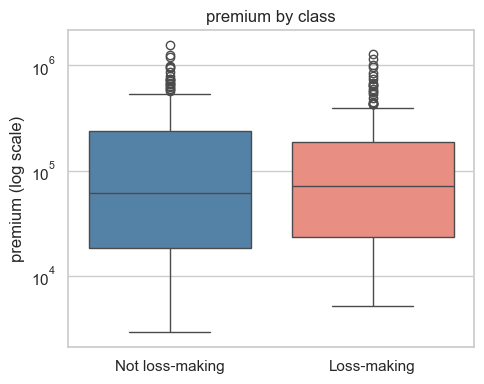

In [58]:
# Box plot — distribution of premium by class
df_plot = df.copy()
df_plot["Class"] = df_plot["is_loss_making"].map({False: "Not loss-making", True: "Loss-making"})
fig, ax = plt.subplots(figsize=(5, 4))
sns.boxplot(
    data=df_plot, x="Class", y="premium", ax=ax,
    palette={"Not loss-making": "steelblue", "Loss-making": "salmon"},
    order=["Not loss-making", "Loss-making"],
)
ax.set_yscale("log")
ax.set_ylabel("premium (log scale)")
ax.set_title("premium by class")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

## Prior Claims

`prior_claims` is the number of previous claims on this policy. I'll check for outliers and visualise.

In [74]:
df['prior_claims'].sort_values().head(10)

245    0.0
203    0.0
106    0.0
107    0.0
395    0.0
109    0.0
110    0.0
296    0.0
103    0.0
112    0.0
Name: prior_claims, dtype: float64

In [80]:
df['prior_claims'].dropna().sort_values().tail(10)

94     4.0
74     4.0
281    4.0
111    4.0
217    4.0
360    4.0
479    4.0
197    4.0
11     5.0
70     5.0
Name: prior_claims, dtype: float64

The values range from 0 to 5, which is plausible for a claims count field. No extreme outliers.

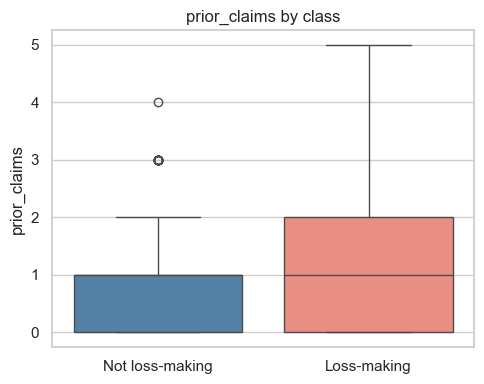

In [81]:
df_plot = df.copy()
df_plot["Class"] = df_plot["is_loss_making"].map({False: "Not loss-making", True: "Loss-making"})

fig, ax = plt.subplots(figsize=(5, 4))
sns.boxplot(
    data=df_plot, x="Class", y="prior_claims", ax=ax,
    palette={"Not loss-making": "steelblue", "Loss-making": "salmon"},
    order=["Not loss-making", "Loss-making"],
)
ax.set_ylabel("prior_claims")
ax.set_title("prior_claims by class")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

## Years Trading

How long the insured entity has been trading. I'll check for outliers — negative values are impossible here.

In [86]:
df['years_trading'].sort_values().head(10)

269    1.0
351    1.0
100    1.0
202    1.0
400    1.0
395    1.0
303    1.0
266    1.0
3      1.0
4      1.0
Name: years_trading, dtype: float64

There are 2 rows with negative `years_trading` values (-3 and -1), which are impossible. These are transcription errors — I'll cast them to the median, consistent with the policy applied to `limit` and `premium`.

In [84]:
median_years_trading = df['years_trading'].median()
df.loc[df['years_trading'] < 0, 'years_trading'] = median_years_trading

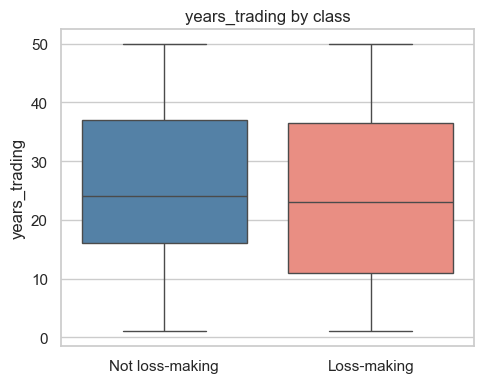

In [85]:
df_plot = df.copy()
df_plot["Class"] = df_plot["is_loss_making"].map({False: "Not loss-making", True: "Loss-making"})

fig, ax = plt.subplots(figsize=(5, 4))
sns.boxplot(
    data=df_plot, x="Class", y="years_trading", ax=ax,
    palette={"Not loss-making": "steelblue", "Loss-making": "salmon"},
    order=["Not loss-making", "Loss-making"],
)
ax.set_ylabel("years_trading")
ax.set_title("years_trading by class")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

# Categories


--- risk_type ---
risk_type
marine       111
cyber        108
property     106
aviation      92
liability     87

--- territory ---
territory
eu       111
uk       108
latam    107
apac     102
us        76

--- industry ---
industry
energy                78
healthcare            74
retail                74
transport             70
manufacturing         69
technology            59
financial_services    59

--- broker ---
broker
meridian re             82
hartwell & sons         77
caldwell specialty      72
brockton & gray         72
alston risk partners    72
nexus broking           68
pinnacle mga            61


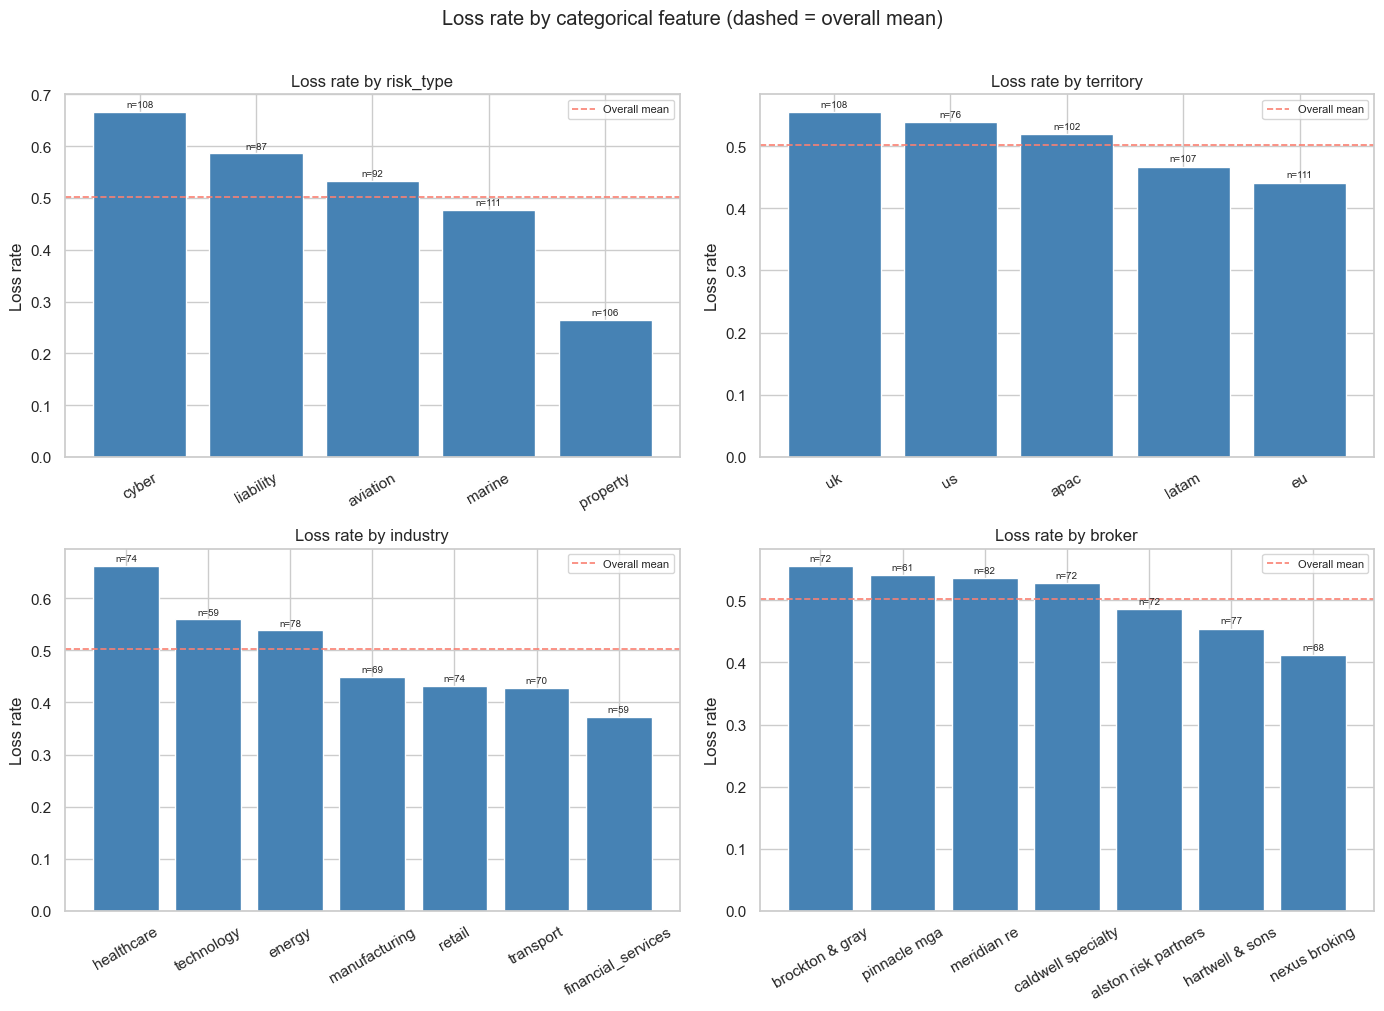

In [87]:
cat_cols = ["risk_type", "territory", "industry", "broker"]

for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().to_string())

# Loss rate by category
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    loss_rate = (
        df.groupby(col)["is_loss_making"]
        .agg(["sum", "count"])
        .rename(columns={"sum": "loss_count", "count": "total"})
    )
    loss_rate["loss_rate"] = loss_rate["loss_count"] / loss_rate["total"]
    loss_rate = loss_rate.sort_values("loss_rate", ascending=False)

    bars = ax.bar(loss_rate.index, loss_rate["loss_rate"], color="steelblue")
    ax.axhline(df["is_loss_making"].mean(), color="salmon", linestyle="--", linewidth=1.2, label="Overall mean")
    ax.set_title(f"Loss rate by {col}")
    ax.set_ylabel("Loss rate")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(fontsize=8)

    for bar, (_, row) in zip(bars, loss_rate.iterrows()):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"n={int(row['total'])}",
            ha="center", va="bottom", fontsize=7,
        )

plt.suptitle("Loss rate by categorical feature (dashed = overall mean)", y=1.01)
plt.tight_layout()
plt.show()

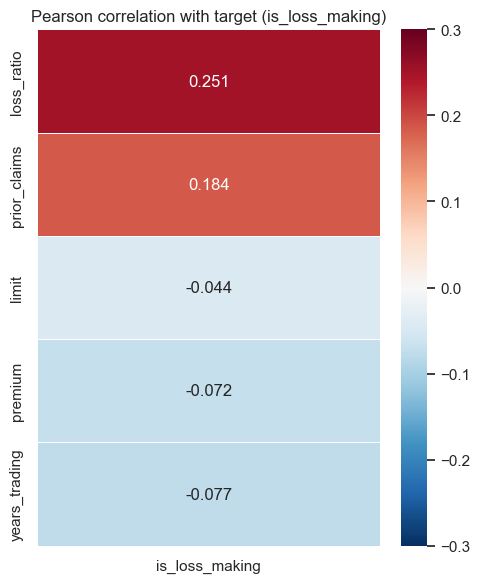

In [88]:
# Correlations between numeric features and the target
corr_df = df[["limit", "premium", "prior_claims", "years_trading", "loss_ratio", "is_loss_making"]].copy()
corr_df["is_loss_making"] = corr_df["is_loss_making"].astype(int)

corr = corr_df.corr()[["is_loss_making"]].drop("is_loss_making").sort_values("is_loss_making", ascending=False)

fig, ax = plt.subplots(figsize=(5, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".3f",
    cmap="RdBu_r",
    center=0,
    vmin=-0.3,
    vmax=0.3,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Pearson correlation with target (is_loss_making)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## Missing Values

Before feature engineering, handle missing values in the dataset:
- `prior_claims` and `years_trading`: ~4% missing — impute with median (robust to skew)
- `industry`: ~4% missing — impute with `'unknown'` to preserve rows

In [89]:
df_model = df.copy()

# Impute numeric missings with median (robust to skew)
for col in ["prior_claims", "years_trading"]:
    median_val = df_model[col].median()
    df_model[col] = df_model[col].fillna(median_val)
    print(f"  {col}: filled {df[col].isnull().sum()} NaN(s) with median={median_val}")

# Impute industry with 'unknown'
df_model["industry"] = df_model["industry"].fillna("unknown")
print(f"  industry: filled {df['industry'].isnull().sum()} NaN(s) with 'unknown'")

print("\nRemaining missing values:")
remaining = df_model.isnull().sum()
print(remaining[remaining > 0] if remaining.any() else "None")

  prior_claims: filled 20 NaN(s) with median=1.0
  years_trading: filled 20 NaN(s) with median=23.75
  industry: filled 21 NaN(s) with 'unknown'

Remaining missing values:
None


## 2. Feature Engineering

Prepare the features for modelling. Think about:
- How to handle missing values
- How to encode categorical variables
- Whether any new features would be informative (e.g. premium rate = premium / limit)
- Whether to drop any columns (e.g. `loss_ratio` — why?)

In [90]:
# Missing values were already imputed in the section above — df_model is clean here.

In [91]:
# encode categorical variables using target encoding
#
# Target encoding replaces each category with its mean target value (loss rate),
# giving the model a single numeric feature per categorical column rather than
# one-hot dummies. This consolidates the categorical signal into one interpretable
# feature (e.g. "broker" → one importance score, not seven fragmented ones).
#
# Leakage prevention: the encoder is fit ONLY on the training split, then applied
# to both train and test. We therefore split before encoding.

cat_cols = ["risk_type", "territory", "industry", "broker"]

# --- split first, before any target-aware encoding ---
drop_cols = ["loss_ratio", "record_id", "is_loss_making"]
feature_cols_raw = [c for c in df_model.columns if c not in drop_cols]

X_raw = df_model[feature_cols_raw].copy()
y = df["is_loss_making"].astype(int)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

# --- fit encoder on train only, transform both splits ---
encoder = ce.TargetEncoder(cols=cat_cols, smoothing=1.0)
encoder.fit(X_train_raw, y_train)

X_train = encoder.transform(X_train_raw)
X_test  = encoder.transform(X_test_raw)

# Keep a full encoded copy for cross-validation later
X = encoder.transform(X_raw)

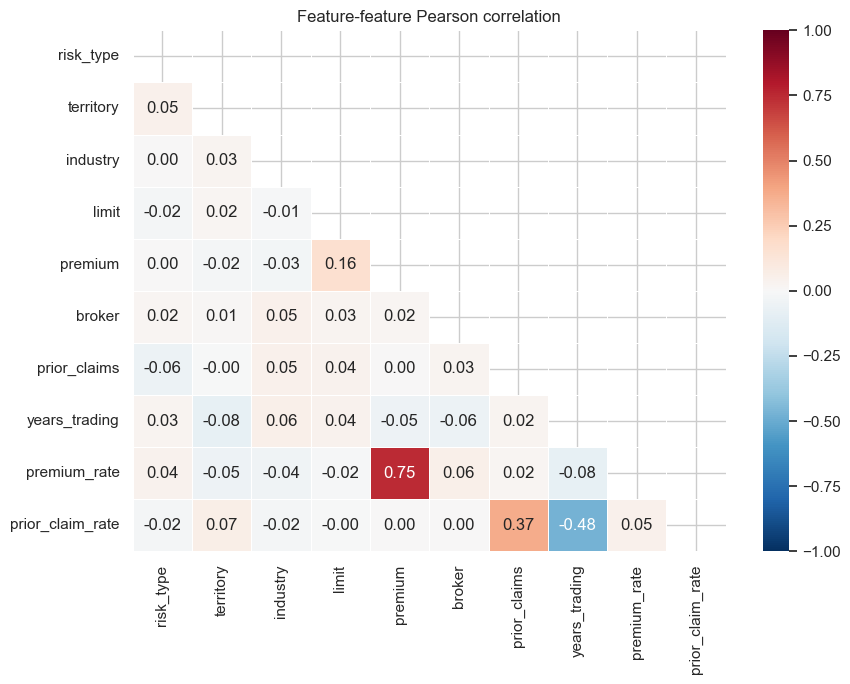

Train: 403 rows  (50.1% loss-making)
Test:  101 rows  (50.5% loss-making)


In [93]:
# premium_rate = premium / limit — captures how thinly the risk is priced relative to exposure
for split in [X_train, X_test, X]:
    split["premium_rate"] = split["premium"] / split["limit"].replace(0, np.nan)
    split["premium_rate"] = split["premium_rate"].fillna(0)

    split["prior_claim_rate"] = split["prior_claims"] / split["years_trading"].replace(0, np.nan)
    split["prior_claim_rate"] = split["prior_claim_rate"].fillna(100)

# Feature-feature correlation matrix
corr_ff = X.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_ff, dtype=bool))
sns.heatmap(
    corr_ff,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Feature-feature Pearson correlation")
plt.tight_layout()
plt.show()

print(f"Train: {X_train.shape[0]} rows  ({y_train.mean()*100:.1f}% loss-making)")
print(f"Test:  {X_test.shape[0]} rows  ({y_test.mean()*100:.1f}% loss-making)")

## 3. Model Training

Choose a model and train it. A few pointers:
- Think about what metrics matter here — accuracy, precision, recall, AUC?
- An explainable model is preferred: logistic regression, decision tree, or an interpreted gradient boosting model
- Be honest about what the model can and cannot do

In [94]:
# train/test split was performed inside the encoding cell to prevent target leakage.
# Confirming split sizes here.
print(f"Train: {X_train.shape[0]} rows  ({y_train.mean()*100:.1f}% loss-making)")
print(f"Test:  {X_test.shape[0]} rows  ({y_test.mean()*100:.1f}% loss-making)")

Train: 403 rows  (50.1% loss-making)
Test:  101 rows  (50.5% loss-making)


In [95]:
from sklearn.calibration import CalibratedClassifierCV

# Build and train the pipeline
#
# GradientBoostingClassifier chosen because:
#   - Handles mixed numeric/encoded-categorical features well
#   - Tree-based: scale-invariant, so no StandardScaler needed
#   - Produces calibrated probabilities via predict_proba, useful for risk ranking
#   - Good performance on small/imbalanced tabular datasets

gbm = GradientBoostingClassifier(
    n_estimators=50,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42,
)

# Calibrate the GBM probabilities using Platt scaling (sigmoid).
# We wrap the already-fitted clf using clone+refit on a validation fold
# to avoid the deprecated cv="prefit" path in sklearn >= 1.6.
# Using cross_val_predict internally with cv=5 to calibrate without leakage.
calibrated_clf = CalibratedClassifierCV(
    gbm, method="sigmoid", cv=5
)
calibrated_clf.fit(X_train, y_train)

# Verify calibration
y_proba_cal = calibrated_clf.predict_proba(X_test)[:, 1]
print(f"Calibrated ROC-AUC: {roc_auc_score(y_test, y_proba_cal):.3f}")
print(f"Probability range:  [{y_proba_cal.min():.3f}, {y_proba_cal.max():.3f}]")

Calibrated ROC-AUC: 0.724
Probability range:  [0.284, 0.752]


=== Classification Report ===
                 precision    recall  f1-score   support

Not loss-making       0.64      0.68      0.66        50
    Loss-making       0.67      0.63      0.65        51

       accuracy                           0.65       101
      macro avg       0.65      0.65      0.65       101
   weighted avg       0.65      0.65      0.65       101

Average Precision (PR-AUC): 0.776

Note on metrics:
  We care more about recall (catching actual losses) than precision.
  A missed loss is more costly than a false alarm for a reviewer to check.
  PR-AUC is the primary metric — directly measures the precision/recall trade-off
  and is more interpretable for this use case than ROC-AUC.


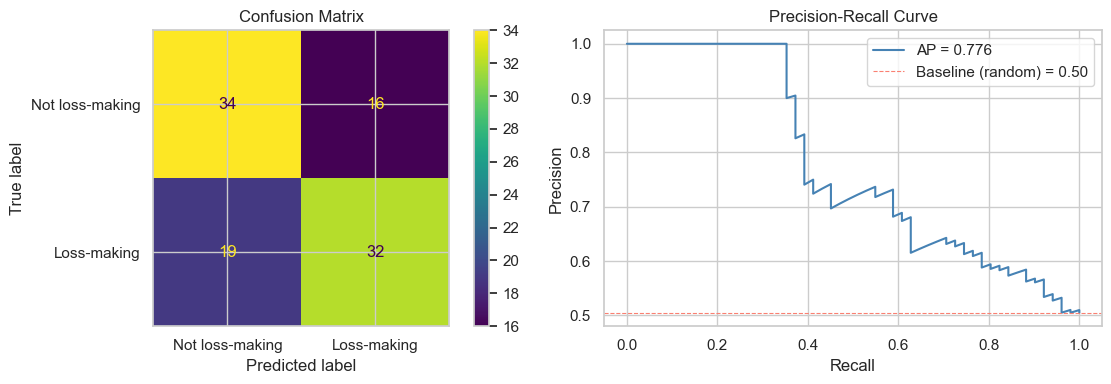

In [100]:
# evaluate — classification report, PR-AUC, confusion matrix
from sklearn.metrics import precision_recall_curve, average_precision_score

y_pred = calibrated_clf.predict(X_test)
y_proba = calibrated_clf.predict_proba(X_test)[:, 1]

print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=["Not loss-making", "Loss-making"]))

ap = average_precision_score(y_test, y_proba)
print(f"Average Precision (PR-AUC): {ap:.3f}")

print("\nNote on metrics:")
print("  We care more about recall (catching actual losses) than precision.")
print("  A missed loss is more costly than a false alarm for a reviewer to check.")
print("  PR-AUC is the primary metric — directly measures the precision/recall trade-off")
print("  and is more interpretable for this use case than ROC-AUC.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["Not loss-making", "Loss-making"], ax=axes[0]
)
axes[0].set_title("Confusion Matrix")

precision, recall, _ = precision_recall_curve(y_test, y_proba)
baseline = y_test.mean()
axes[1].plot(recall, precision, label=f"AP = {ap:.3f}", color="steelblue")
axes[1].axhline(baseline, color="salmon", linestyle="--", linewidth=0.8,
                label=f"Baseline (random) = {baseline:.2f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

SHAP summary plot — mean |SHAP value| across training set


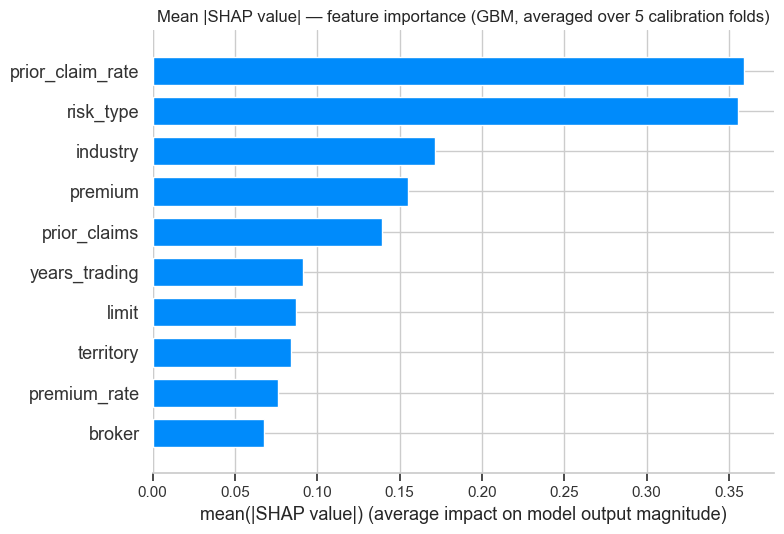


Beeswarm plot — direction and magnitude of each feature's effect


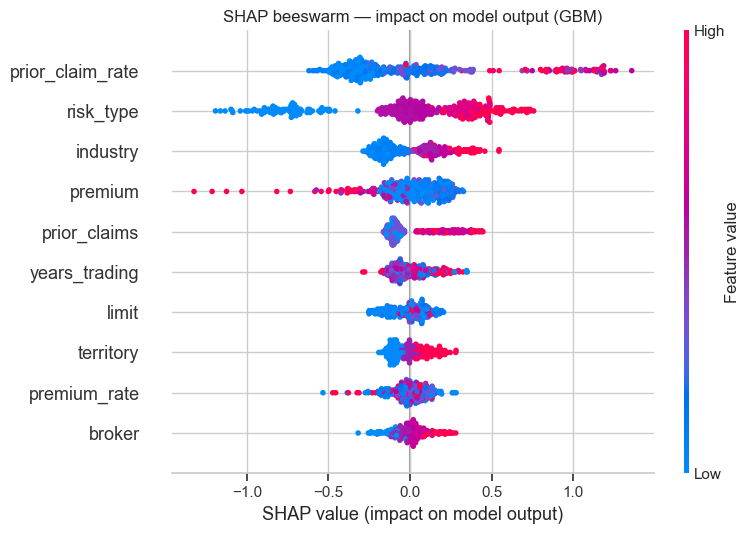


Limitations:
  - SHAP values show the marginal contribution of each feature to each prediction,
    relative to the expected model output (base rate).
  - Averaged over 5 calibration folds; individual folds may differ slightly.
  - 504 training rows is small; SHAP values may shift with more data.
  - Target encoding consolidates categorical signal into one numeric feature per column,
    making SHAP cleaner than one-hot (no fragmentation across broker_X dummies).
  - SHAP measures association, not causation.


In [99]:
import shap

# CalibratedClassifierCV with cv=5 fits 5 base estimators internally.
# We average SHAP values across all 5 folds for a more stable explanation.
shap_vals_list = []
for cc in calibrated_clf.calibrated_classifiers_:
    explainer = shap.TreeExplainer(cc.estimator)
    shap_vals_list.append(explainer.shap_values(X_train))

shap_values = np.mean(shap_vals_list, axis=0)

print("SHAP summary plot — mean |SHAP value| across training set")
shap.summary_plot(shap_values, X_train, plot_type="bar", show=False)
plt.title("Mean |SHAP value| — feature importance (GBM, averaged over 5 calibration folds)")
plt.tight_layout()
plt.show()

print("\nBeeswarm plot — direction and magnitude of each feature's effect")
shap.summary_plot(shap_values, X_train, show=False)
plt.title("SHAP beeswarm — impact on model output (GBM)")
plt.tight_layout()
plt.show()

print("\nLimitations:")
print("  - SHAP values show the marginal contribution of each feature to each prediction,")
print("    relative to the expected model output (base rate).")
print("  - Averaged over 5 calibration folds; individual folds may differ slightly.")
print("  - 504 training rows is small; SHAP values may shift with more data.")
print("  - Target encoding consolidates categorical signal into one numeric feature per column,")
print("    making SHAP cleaner than one-hot (no fragmentation across broker_X dummies).")
print("  - SHAP measures association, not causation.")

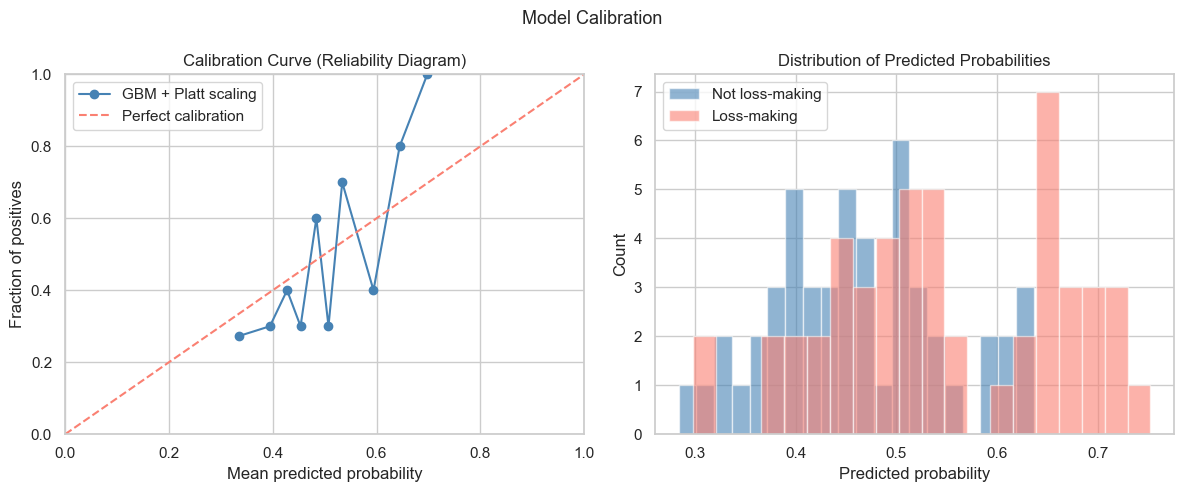

A well-calibrated model should have points close to the diagonal in the reliability diagram.
Points above the diagonal → model under-predicts; points below → over-predicts.


In [102]:
from sklearn.calibration import calibration_curve

# Calibration curve (reliability diagram)
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10, strategy="quantile")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Reliability diagram ---
ax = axes[0]
ax.plot(prob_pred, prob_true, marker="o", color="steelblue", label="GBM + Platt scaling")
ax.plot([0, 1], [0, 1], linestyle="--", color="salmon", label="Perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title("Calibration Curve (Reliability Diagram)")
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# --- Predicted probability histogram ---
ax2 = axes[1]
ax2.hist(y_proba[y_test == 0], bins=20, alpha=0.6, color="steelblue", label="Not loss-making")
ax2.hist(y_proba[y_test == 1], bins=20, alpha=0.6, color="salmon", label="Loss-making")
ax2.set_xlabel("Predicted probability")
ax2.set_ylabel("Count")
ax2.set_title("Distribution of Predicted Probabilities")
ax2.legend()

plt.suptitle("Model Calibration", fontsize=13)
plt.tight_layout()
plt.show()

print("A well-calibrated model should have points close to the diagonal in the reliability diagram.")
print("Points above the diagonal → model under-predicts; points below → over-predicts.")

### Calibration Interpretation

**Reliability diagram (left)**

The curve should ideally follow the dashed diagonal — meaning that when the model predicts a 40% probability of loss, roughly 40% of those records truly are loss-making. The overall trend is broadly aligned with the diagonal, indicating that Platt scaling has done its job. However, the curve is noticeably erratic, oscillating above and below the ideal line. This is expected: with only ~101 test records spread across 10 bins, each bin contains roughly 10 observations, so a single misclassification swings the fraction of positives by ~10 percentage points. The noise here is a **small sample artefact**, not evidence of systematic miscalibration.

In the mid-range (predicted probabilities 0.35–0.55), the model tends to slightly **over-predict** — the fraction of actual positives sits below the diagonal. At higher probabilities (≥0.6) the model **under-predicts**, with the final bin jumping sharply to 1.0; this last point is driven by very few records and should not be over-interpreted.

**Probability histogram (right)**

Both classes are clustered tightly between approximately 0.28 and 0.75 — the model never issues a confident prediction near 0 or 1. A well-separating model would push the two distributions apart; here they overlap substantially, which is consistent with the 65% accuracy and ROC-AUC of 0.724. There is nevertheless a modest shift: the not-loss-making distribution peaks around 0.40–0.45, while the loss-making distribution peaks slightly higher around 0.55–0.65, confirming the model has learned *some* discriminative signal.

**Overall**

Calibration is moderate and broadly appropriate for use as a **risk-ranking tool** — records with higher predicted probabilities are genuinely more likely to be loss-making. However, the absolute probability values should be treated with caution given the small dataset (~504 rows). With more data, both the calibration curve and the class separation in the histogram would be expected to improve considerably.

## 4. Save Model Artifact

Save your trained model to `../app/artifacts/model.pkl` so the app can load it.

If you built a preprocessing pipeline, save the full pipeline (not just the estimator), so the app can call `pipeline.predict()` directly on raw records.

In [101]:
ARTIFACT_PATH = Path("../app/artifacts/model.pkl")
ARTIFACT_PATH.parent.mkdir(parents=True, exist_ok=True)

with ARTIFACT_PATH.open("wb") as f:
    pickle.dump(calibrated_clf, f)

print(f"Model saved to {ARTIFACT_PATH}")
print("Artifact: CalibratedClassifierCV (GradientBoostingClassifier + Platt scaling, cv=5)")
print("Call calibrated_clf.predict(X) or calibrated_clf.predict_proba(X) on preprocessed feature DataFrames.")

Model saved to ..\app\artifacts\model.pkl
Artifact: CalibratedClassifierCV (GradientBoostingClassifier + Platt scaling, cv=5)
Call calibrated_clf.predict(X) or calibrated_clf.predict_proba(X) on preprocessed feature DataFrames.
